In [1]:
# ── 0. SETUP ──────────────────────────────────────────────────────────────────
import os
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StringType, IntegerType, FloatType, ArrayType,
    StructType, StructField, LongType, DoubleType
)

from config import build_spark_session
spark = build_spark_session("MyDigitalTwin-FusionViz")
spark.sparkContext.setLogLevel("WARN")

# ── Config centrale ────────────────────────────────────────────────────────────
import sys as _sys, os as _os
_d = _os.path.abspath('')
while not _os.path.exists(_os.path.join(_d, 'config.py')):
    _p = _os.path.dirname(_d)
    if _p == _d: raise RuntimeError("config.py introuvable")
    _d = _p
if _d not in _sys.path: _sys.path.insert(0, _d)
from config import WAREHOUSE

print(f"Warehouse: {WAREHOUSE}")
assert os.path.exists(WAREHOUSE), f"Warehouse introuvable: {WAREHOUSE}"

def read_table(name):
    return spark.read.format("delta").load(os.path.join(WAREHOUSE, name))


Warehouse: /opt/spark/data/warehouse


26/04/27 23:16:25 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


---
## PARTIE C — Fusion simplifiée → interest_profiles

Content clustering abandonné (clusters TF-IDF trop hétérogènes). On utilise uniquement les **profils comportementaux** comme base des `interest_profiles`.

**Approche** :
1. Charger `data/warehouse/behavioral_clusters` (6 profils déjà écrits)
2. Pour chaque cluster, extraire dynamiquement les top keywords depuis la source dominante (youtube `title`, google `query`, spotify `artistName`, netflix `show_title`, chrome `title`)
3. Écrire `data/warehouse/interest_profiles` avec le schéma attendu par `home.py`

In [2]:
# ── C1. CHARGEMENT DES PROFILS COMPORTEMENTAUX ────────────────────────────────
beh_clusters = read_table("behavioral_clusters")

print("Profils comportementaux :")
beh_clusters.show(truncate=60)

# Dict Python pour usage dans les cellules suivantes
beh_info = {row["cluster_id"]: row.asDict() for row in beh_clusters.collect()}
print(f"\n{len(beh_info)} clusters chargés.")

Profils comportementaux :


26/04/27 23:16:41 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------+---------------------------------+-----+--------+-----------+-----------+--------+------------------------------------------------------------+----------+
|cluster_id|                            label|emoji|avg_hour|avg_weekday|time_period|day_type|                                               top_platforms|item_count|
+----------+---------------------------------+-----+--------+-----------+-----------+--------+------------------------------------------------------------+----------+
|         0| 📱 Réseaux & Médias · Après-midi|   📱|    14.5|        4.0| Apres-midi| Semaine|[youtube, google, spotify, tiktok, tiktok_likes, tiktok_s...|    201989|
|         1|🌐 Navigation Chrome · Après-midi|   🌐|    13.9|        3.5| Apres-midi| Semaine|                                                    [chrome]|       338|
|         2|         👻 Sauvegardes IG · Rare|   👻|    15.7|        3.9| Apres-midi| Semaine|                                           [instagram_saved]|        17|
|   

In [3]:
# ── C2. EXTRACTION DYNAMIQUE DES KEYWORDS + SAMPLES PAR CLUSTER ──────────────
# On dérive les keywords depuis top_platforms de chaque cluster → pas d'IDs hardcodés.

from pyspark.ml.feature import Tokenizer, StopWordsRemover, NGram

STOPWORDS_EXTRA = [
    # Français
    "les","des","une","sur","avec","dans","qui","que","par","plus",
    "tout","bien","comme","mais","mon","ton","son","nos","mes",
    "faire","comment","aussi","encore","très",
    # Anglais générique
    "the","and","for","with","you","your","this","that","from",
    "are","was","not","its","but","all","new","best","how",
    # Bruit vidéo/URL
    "https","http","www","com","org","net","html","utm","amp",
    "watch","video","clip","official","officiel","youtube","shorts",
    "16x9","inh","vid","1920x1080","15s","officiel)","(clip",
    "(official","video)","(ft","music","choisissez","chrome",
    # Bruit chrome / email
    "google","gmail","recherche","online","redirect","editor",
    # Bruit Spotify
    "lil","trio","los","del","les","von",
]
STOP_ALL = (StopWordsRemover.loadDefaultStopWords("english")
          + StopWordsRemover.loadDefaultStopWords("french")
          + STOPWORDS_EXTRA)


def extract_top_words(df, text_col, n=15):
    clean = (
        df.filter(F.col(text_col).isNotNull() & (F.length(F.col(text_col)) > 2))
        .withColumnRenamed(text_col, "_text")
        .filter(~F.col("_text").rlike(r'@|^https?://|%[0-9a-fA-F]{2}'))
    )
    tok = Tokenizer(inputCol="_text", outputCol="_words").transform(clean)
    flt = StopWordsRemover(inputCol="_words", outputCol="_tokens",
                           stopWords=STOP_ALL).transform(tok)
    return (flt.select(F.explode("_tokens").alias("w"))
               .filter(F.length("w") > 2)
               .filter(~F.col("w").rlike(r'^\d'))
               .filter(~F.col("w").rlike(r'[@%#\(\)]'))
               .groupBy("w").count()
               .orderBy(F.desc("count")).limit(n)
               .select("w").rdd.flatMap(lambda x: x).collect())


def extract_bigrams(df, text_col, n=5):
    clean = (
        df.filter(F.col(text_col).isNotNull() & (F.length(F.col(text_col)) > 2))
        .withColumnRenamed(text_col, "_text")
        .filter(~F.col("_text").rlike(r'@|^https?://|%[0-9a-fA-F]{2}'))
    )
    tok = Tokenizer(inputCol="_text", outputCol="_words").transform(clean)
    flt = StopWordsRemover(inputCol="_words", outputCol="_tokens",
                           stopWords=STOP_ALL).transform(tok)
    bg  = NGram(n=2, inputCol="_tokens", outputCol="_ng").transform(flt)
    return (bg.select(F.explode("_ng").alias("b"))
              .filter(F.length("b") > 5)
              .filter(~F.col("b").rlike(r'[@%#\(\)\d]'))
              .groupBy("b").count()
              .orderBy(F.desc("count")).limit(n)
              .select("b").rdd.flatMap(lambda x: x).collect())


NOISE_RE = (
    r'(?i)'
    r'\b\d{1,4}x\d{1,4}\b|\bINH\b'
    r'|Choisissez Chrome|Kies Chrome|Choose Chrome'
    r'|^Redirect(?:ion)?[\.\s…]*$|Ad Blocker|VID\s+\d'
    r'|_[A-Z]{2}\b|\bBoost_\d|LinkedAccounts|FreeBankAccount'
    r'|\b\d+\s*sec\b|casino|^Shortened[:\s]'
    r'|[一-鿿぀-ヿ]'
    r'|\blening\b|\bkrediet\b|CI/CD|TeamCity|JetBrains'
    r'|On the jobsite|leaders aren|\bvolvo\b|\bDEWALT\b'
    r'|reconditionné.*Back\s*Mark|Enjoy a better|^Loading[.\s]*$'
    r'|lust\s+god|Recherche\s+Google|(\w+)\s+\1\.(com|net|org|be|fr|io)'
)

def extract_samples(df, text_col, n=30):
    return (
        df.filter(F.col(text_col).isNotNull() & (F.length(F.col(text_col)) > 1))
        .filter(~F.col(text_col).rlike(r'@|^https?://|%[0-9a-fA-F]{2}'))
        .filter(~F.col(text_col).rlike(NOISE_RE))
        .filter(~F.col(text_col).rlike(r'^\s*[A-Z0-9_]{5,}\s'))
        .groupBy(text_col).count()
        .orderBy(F.desc("count")).limit(n)
        .select(text_col).rdd.flatMap(lambda x: x).collect()
    )


def merge_kw(*lists):
    seen, result = set(), []
    for lst in lists:
        for w in lst:
            if w not in seen:
                seen.add(w); result.append(w)
    return result


# ── Mapping plateforme → (table, colonne texte) ───────────────────────────────
PLATFORM_SOURCE = {
    "youtube":           ("youtube_watch",      "title"),
    "google":            ("google_searches",    "query"),
    "chrome":            ("google_chrome",      "title"),
    "spotify":           ("spotify_streams",    "artistName"),
    "netflix":           ("netflix_views",      "show_title"),
    "tiktok":            ("tiktok_searches",    "query"),
    "tiktok_likes":      ("tiktok_searches",    "query"),
    "tiktok_search":     ("tiktok_searches",    "query"),
    "instagram":         ("instagram_searches", "query"),
    "instagram_saved":   ("instagram_searches", "query"),
    "ig_search":         ("instagram_searches", "query"),
    "ig_posts":          ("instagram_searches", "query"),
    "ig_videos":         ("instagram_searches", "query"),
    "ig_stories":        ("instagram_searches", "query"),
    "instagram_comment": ("instagram_searches", "query"),
    "twitter":           ("twitter_tweets",     "full_text"),
}

# ── Chargement unique des sources (cache) ─────────────────────────────────────
_DF_CACHE = {}
def get_df(table_name):
    if table_name not in _DF_CACHE:
        try:
            _DF_CACHE[table_name] = read_table(table_name).cache()
        except Exception:
            _DF_CACHE[table_name] = None
    return _DF_CACHE[table_name]

# ── Extraction dynamique par cluster ─────────────────────────────────────────
CLUSTER_KEYWORDS = {}
CLUSTER_SAMPLES  = {}

for cid, info in sorted(beh_info.items()):
    platforms = list(info.get("top_platforms") or [])
    seen_tables, kw_parts, sample_parts = set(), [], []

    for p in platforms:
        mapping = PLATFORM_SOURCE.get(p)
        if not mapping:
            continue
        table_name, text_col = mapping
        if table_name in seen_tables:
            continue
        df = get_df(table_name)
        if df is None:
            continue
        seen_tables.add(table_name)
        kw_parts.append(extract_bigrams(df, text_col, n=4))
        kw_parts.append(extract_top_words(df, text_col, n=12))
        sample_parts.append(extract_samples(df, text_col, n=20))
        if len(seen_tables) >= 3:   # max 3 sources par cluster
            break

    CLUSTER_KEYWORDS[cid] = merge_kw(*kw_parts)

    # Déduplique les samples cross-sources
    all_s, seen_s = [], set()
    for lst in sample_parts:
        for s in lst:
            if s not in seen_s:
                seen_s.add(s); all_s.append(s)
    CLUSTER_SAMPLES[cid] = all_s[:30]

    label = info["label"]
    print(f"  [{cid}] {label}")
    print(f"       sources : {sorted(seen_tables)}")
    print(f"       keywords: {CLUSTER_KEYWORDS[cid][:8]}")
    print()


  [0] 📱 Réseaux & Médias · Après-midi
       sources : ['google_searches', 'spotify_streams', 'youtube_watch']
       keywords: ['- rediffusion', 'rediffusion squeezie', 'travis scott', 'inazuma eleven', 'mix', 'live', 'house', 'squeezie']

  [1] 🌐 Navigation Chrome · Après-midi
       sources : ['google_chrome']
       keywords: ['| photo', 'photopea |', 'nozgap -', 'bad bunny', 'photopea', 'nozgap', 'photo', 'stuttgart']

  [2] 👻 Sauvegardes IG · Rare
       sources : []
       keywords: []

  [3] 🎬 Netflix · Soirée
       sources : ['netflix_views']
       keywords: ['naruto shippuden', 'x hunter', 'hunter x', 'fairy tail', 'naruto', 'shippuden', 'hunter', 'fairy']



In [4]:
# ── C3. ÉCRITURE interest_profiles ────────────────────────────────────────────
# CLUSTER_KEYWORDS et CLUSTER_SAMPLES sont calculés dynamiquement en C2.

schema_ip = StructType([
    StructField("cluster_id",    IntegerType(), False),
    StructField("label",         StringType(),  False),
    StructField("emoji",         StringType(),  True),
    StructField("keywords",      ArrayType(StringType()), True),
    StructField("top_platforms", ArrayType(StringType()), True),
    StructField("avg_hour",      DoubleType(),  True),
    StructField("time_period",   StringType(),  True),
    StructField("day_type",      StringType(),  True),
    StructField("item_count",    LongType(),    True),
    StructField("sample_items",  ArrayType(StringType()), True),
])

interest_rows = [
    (
        cid,
        info["label"],
        info["emoji"],
        CLUSTER_KEYWORDS.get(cid, []),
        list(info.get("top_platforms") or []),
        float(info["avg_hour"]),
        info["time_period"],
        info["day_type"],
        info["item_count"],
        CLUSTER_SAMPLES.get(cid, []),
    )
    for cid, info in sorted(beh_info.items())
]

interest_profiles_df = spark.createDataFrame(interest_rows, schema_ip)

out_path = os.path.join(WAREHOUSE, "interest_profiles")
interest_profiles_df.write.mode("overwrite").parquet(out_path)

print(f"✅ Écrit dans : {out_path}\n")
interest_profiles_df.select("cluster_id", "label", "sample_items", "item_count").show(truncate=70)


✅ Écrit dans : /opt/spark/data/warehouse/interest_profiles

+----------+---------------------------------+----------------------------------------------------------------------+----------+
|cluster_id|                            label|                                                          sample_items|item_count|
+----------+---------------------------------+----------------------------------------------------------------------+----------+
|         0| 📱 Réseaux & Médias · Après-midi|[Gazo - Guinea Man [Mixtape], Damso - Jean Reno, DJ ZAYON - SALEGY ...|    201989|
|         1|🌐 Navigation Chrome · Après-midi|[Photopea | Online Photo Editor, AliExpress - Online winkelen voor ...|       338|
|         2|         👻 Sauvegardes IG · Rare|                                                                    []|        17|
|         3|              🎬 Netflix · Soirée|[Naruto Shippuden, Naruto, Hunter X Hunter (2011), Fairy Tail, JoJo...|      4288|
+----------+-----------------------------

---
## PARTIE D — Visualisation des profils comportementaux

PCA sur TF-IDF abandonnée (content clustering retiré). On visualise à la place :
- **Bar chart** : volume d'activité par profil
- **Scatter heure** : heure moyenne d'activité par profil (taille ∝ volume)

In [5]:
# ── D0. DÉPENDANCES VISUALISATION ─────────────────────────────────────────────
%pip install --quiet matplotlib numpy


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/tmp/ipykernel_19135/3067066147.py:41: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19135/3067066147.py:41: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19135/3067066147.py:41: UserWarning: Glyph 128123 (\N{GHOST}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19135/3067066147.py:41: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_19135/3067066147.py:46: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  plt.savefig(out_img, dpi=120, bbox_inches="tight")
/tmp/ipykernel_19135/3067066147.py:46: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.savefig(out_img, dpi=120, bbox_inches="tight")
/tmp/ipykernel_19135/3067066147.py:46: UserWarning: Glyph 128123 (\N{GHOST}) missing from fo

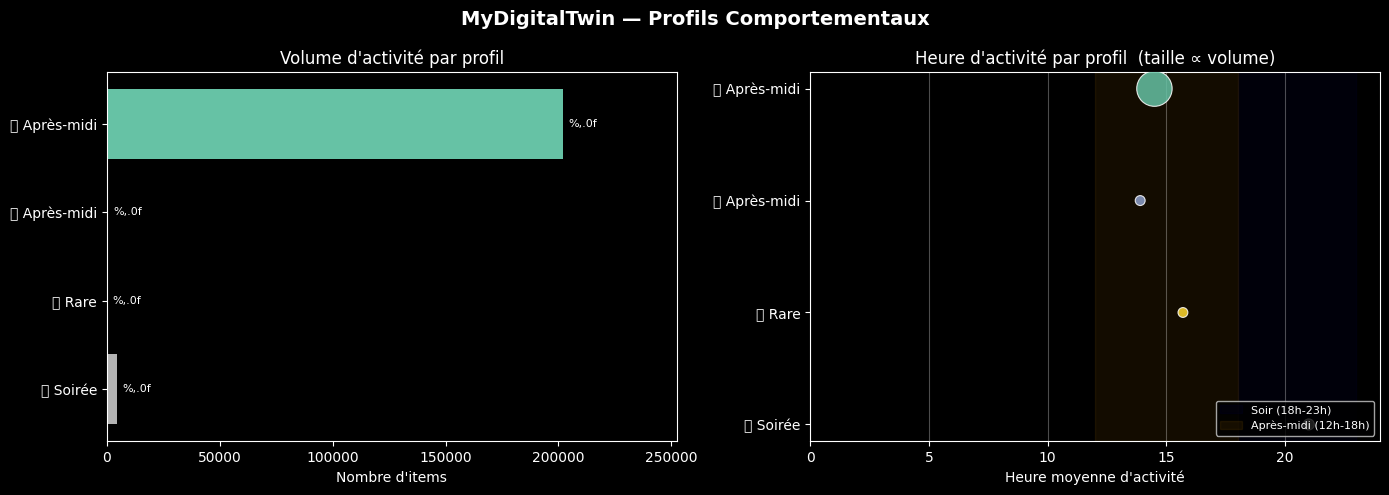

Visualisation sauvegardée : C:/Users/arnau/Documents/MyDigitalTwin/app/assets/behavioral_profiles.png


In [6]:
# ── D1. VISUALISATION — PROFILS COMPORTEMENTAUX ───────────────────────────────
try:
    import matplotlib.pyplot as plt
    import matplotlib.cm as cm
    import numpy as np

    pdf = interest_profiles_df.toPandas()
    pdf = pdf.sort_values("cluster_id").reset_index(drop=True)

    short_labels = [f"{row['emoji']} {row['label'].split('·')[-1].strip()}"
                    for _, row in pdf.iterrows()]
    colors = cm.Set2(np.linspace(0, 1, len(pdf)))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Graphique 1 : Items par cluster ---
    bars = ax1.barh(short_labels, pdf["item_count"], color=colors)
    ax1.set_xlabel("Nombre d'items")
    ax1.set_title("Volume d'activité par profil")
    ax1.bar_label(bars, fmt='%,.0f', padding=4, fontsize=8)
    ax1.set_xlim(0, pdf["item_count"].max() * 1.25)
    ax1.invert_yaxis()

    # --- Graphique 2 : Heure moyenne d'activité ---
    sizes = (pdf["item_count"] / pdf["item_count"].max() * 600 + 50).values
    ax2.scatter(pdf["avg_hour"], range(len(pdf)),
                s=sizes, c=range(len(pdf)), cmap="Set2",
                alpha=0.85, zorder=3, edgecolors="white", linewidths=0.8)
    ax2.set_yticks(range(len(pdf)))
    ax2.set_yticklabels(short_labels)
    ax2.set_xlabel("Heure moyenne d'activité")
    ax2.set_title("Heure d'activité par profil  (taille ∝ volume)")
    ax2.axvspan(18, 23, alpha=0.08, color="navy",   label="Soir (18h-23h)")
    ax2.axvspan(12, 18, alpha=0.08, color="orange", label="Après-midi (12h-18h)")
    ax2.set_xlim(0, 24)
    ax2.legend(loc="lower right", fontsize=8)
    ax2.grid(axis="x", alpha=0.3)
    ax2.invert_yaxis()

    plt.suptitle("MyDigitalTwin — Profils Comportementaux", fontsize=14, fontweight="bold")
    plt.tight_layout()

    ASSETS = "C:/Users/arnau/Documents/MyDigitalTwin/app/assets"
    os.makedirs(ASSETS, exist_ok=True)
    out_img = os.path.join(ASSETS, "behavioral_profiles.png")
    plt.savefig(out_img, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Visualisation sauvegardée : {out_img}")

except ImportError:
    print("matplotlib non disponible — skipping visualization")

In [7]:
spark.stop()
print("Spark session fermée. Notebook terminé.")

Spark session fermée. Notebook terminé.
